In [1]:
import os
import sys
import uproot
import awkward as ak
import numpy as np
from coffea import nanoevents
import vector
from rich import print
import matplotlib.pyplot as plt
import matplotlib
import mplhep as hep
from hist import Hist
from tqdm import tqdm

In [2]:
sys.path.insert(0, "../../workflows/")

In [3]:
matplotlib.rcParams.update({"figure.max_open_warning": 0})
hep.style.use(hep.style.CMS)

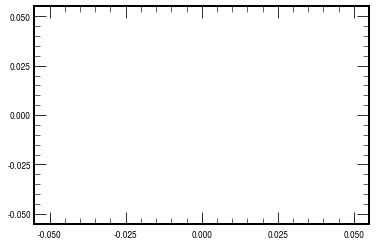

In [4]:
plt.plot()
hep.style.use(hep.style.CMS)

In [5]:
np.set_printoptions(precision=2)

In [6]:
vector.register_awkward()

In [138]:
xrd_path = "root://cmseos.fnal.gov//store/group/lpcsuep/"

qcd = "QCD_Pt-300To470_MuEnrichedPt5_TuneCP5_13TeV-pythia8"
wjets = "WJetsToLNu_HT-70To100_TuneCP5_13TeV-madgraphMLM-pythia8"
dyjets = "DYJetsToLL_M-50_TuneCP5_13TeV-amcatnloFXFX-pythia8"
tt = "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8"
higgs = "GluGluHToZZTo4L_M125_TuneCP5_13TeV_powheg2_minloHJJ_JHUGenV7011_pythia8"
suep = "GluGluToSUEP_T2p00_TuneCP5_13TeV_pythia8_split/SUEP_mS400.000_mPhi8.000_T2.000_modehadronic"
zzto2l2nu = "ZZTo2L2Nu_TuneCP5_13TeV_powheg_pythia8"
zz = "ZZTo2L2Nu_TuneCP5_13TeV_powheg_pythia8"

file = nanoevents.NanoEventsFactory.from_root(
    f"{xrd_path}/Muon_counting_search/SUEPNano_UL18_May2025_merged/{suep}/merged_0.root",
    schemaclass=nanoevents.NanoAODSchema,
)

events = file.events()

In [139]:
muons = events.Muon
clean_muons = (
    (muons.mediumId) & (muons.pt > 3) & (abs(muons.eta) < 2.4) & (abs(muons.dz) < 0.2)
)
muons = muons[clean_muons]
select_by_muons_low = ak.num(muons, axis=-1) > 2
events = events[select_by_muons_low]
muons = muons[select_by_muons_low]

In [140]:
def find_dimuon_pairs(muons, return_indices: bool = False):
    """
    Find recursively all possible pairs of OS muons, starting from the closest in dR.
    Implements a greedy matching algorithm to find the pairs.
    """
    muons1 = muons[muons.charge == 1]
    muons2 = muons[muons.charge == -1]
    muons1_idx = ak.local_index(muons)[muons.charge == 1]
    muons2_idx = ak.local_index(muons)[muons.charge == -1]

    muon_pairs = ak.unzip(ak.cartesian([muons1, muons2], nested=False))
    muon_pairs_idx = ak.unzip(ak.cartesian([muons1_idx, muons2_idx], nested=False))
    muon_pairs_0, muon_pairs_1 = muon_pairs  # type: ignore[index]
    muon_pairs_0_idx, muon_pairs_1_idx = muon_pairs_idx  # type: ignore[index]

    found_0, found_1, idx_0, idx_1 = [], [], [], []

    while ak.any(ak.num(muon_pairs_0) > 0):
        delta_r = muon_pairs_0.delta_r(muon_pairs_1)
        argmin_delta_r = ak.argmin(delta_r, axis=-1, keepdims=True)

        temp_0 = muon_pairs_0[argmin_delta_r]
        temp_1 = muon_pairs_1[argmin_delta_r]
        temp_0_idx = muon_pairs_0_idx[argmin_delta_r]
        temp_1_idx = muon_pairs_1_idx[argmin_delta_r]

        found_0.append(temp_0)
        found_1.append(temp_1)
        idx_0.append(temp_0_idx)
        idx_1.append(temp_1_idx)

        matched_0 = ak.firsts(temp_0_idx)
        matched_1 = ak.firsts(temp_1_idx)

        remove_mask = (muon_pairs_0_idx != matched_0) & (muon_pairs_1_idx != matched_1)
        muon_pairs_0 = muon_pairs_0[remove_mask]
        muon_pairs_1 = muon_pairs_1[remove_mask]
        muon_pairs_0_idx = muon_pairs_0_idx[remove_mask]
        muon_pairs_1_idx = muon_pairs_1_idx[remove_mask]

        if ak.all(ak.num(muon_pairs_0) == 0):
            break

    # Combine results
    if found_0:
        found_pairs_0 = ak.concatenate(found_0, axis=-1)
        found_pairs_1 = ak.concatenate(found_1, axis=-1)
        found_pairs_idx_0 = ak.concatenate(idx_0, axis=-1)
        found_pairs_idx_1 = ak.concatenate(idx_1, axis=-1)
    else:
        # Handle case with no OS pairs anywhere
        # Type preservation
        found_pairs_0 = muons[[]]
        found_pairs_1 = muons[[]]
        found_pairs_idx_0 = muons[[]]
        found_pairs_idx_1 = muons[[]]

    # Ensure the same number of events as input (important!)
    found_pairs_0 = ak.fill_none(found_pairs_0, [], axis=0)
    found_pairs_1 = ak.fill_none(found_pairs_1, [], axis=0)
    found_pairs_idx_0 = ak.fill_none(found_pairs_idx_0, [], axis=0)
    found_pairs_idx_1 = ak.fill_none(found_pairs_idx_1, [], axis=0)

    found_pairs_0 = found_pairs_0[~ak.is_none(found_pairs_0, axis=-1)]
    found_pairs_1 = found_pairs_1[~ak.is_none(found_pairs_1, axis=-1)]
    found_pairs_idx_0 = found_pairs_idx_0[~ak.is_none(found_pairs_idx_0, axis=-1)]
    found_pairs_idx_1 = found_pairs_idx_1[~ak.is_none(found_pairs_idx_1, axis=-1)]

    if return_indices:
        return found_pairs_0, found_pairs_1, found_pairs_idx_0, found_pairs_idx_1

    return found_pairs_0, found_pairs_1


def remove_resonaces(
    events,
    muons,
    dr_matching_threshold: float = 0.3,
    jpsi_window: tuple = (2.7, 3.5),
    upsilon_window: tuple = (8.8, 11.2),
    veto_mode: bool = True,
):
    """
    Remove events with dimuon resonances (J/psi and Upsilon) by forming all
    possible pairs of OS muons and checking their invariant mass.
    If veto_mode is True, events with resonances are removed.
    If veto_mode is False, only muons from resonances are removed.
    """

    if len(events) == 0:
        return events, muons

    muon_pairs_0, muon_pairs_1, muon_pairs_idx_0, muon_pairs_idx_1 = find_dimuon_pairs(  # type: ignore[assignment]
        muons, return_indices=True
    )
    dimuon_dr_mask = muon_pairs_0.delta_r(muon_pairs_1) < dr_matching_threshold
    dimuon_mass = (muon_pairs_0 + muon_pairs_1).mass
    dimuon_mass_mask = (
        (dimuon_mass > jpsi_window[0]) & (dimuon_mass < jpsi_window[1])
    ) | ((dimuon_mass > upsilon_window[0]) & (dimuon_mass < upsilon_window[1]))

    if veto_mode:
        events = events[~ak.any(dimuon_dr_mask & dimuon_mass_mask, axis=1)]
        muons = muons[~ak.any(dimuon_dr_mask & dimuon_mass_mask, axis=1)]
        return events, muons

    # Remove only muons from resonances
    res_mu_idx_0 = muon_pairs_idx_0[dimuon_mass_mask]
    res_mu_idx_1 = muon_pairs_idx_1[dimuon_mass_mask]
    res_mu_idx = ak.concatenate([res_mu_idx_0, res_mu_idx_1], axis=-1)

    pairs = ak.cartesian(
        {"idx": ak.local_index(muons), "rm": res_mu_idx},
        axis=1,
        nested=True,  # make a sublist over "rm" for each muon
    )

    same = pairs["idx"] == pairs["rm"]  # True if this (muon, remove) pair matches
    remove_mask = ak.any(same, axis=-1)  # per muon: True if its index is in res_mu_idx
    keep_mask = ~remove_mask  # invert to keep the others

    muons = muons[keep_mask]

    return events, muons

In [147]:
ak.sum(ak.num(muons) > 6)

9657

In [149]:
_, muons_vetoed = remove_resonaces(events, muons, veto_mode=True)
_, muons_removed = remove_resonaces(events, muons, veto_mode=False)

In [152]:
print(ak.sum(ak.num(muons) > 6))
print(ak.sum(ak.num(muons_vetoed) > 6))
print(ak.sum(ak.num(muons_removed) > 6))

9657

9585

7574

In [117]:
# New method. Just remove matched muons.
muon_pairs_0, muon_pairs_1, muon_pairs_idx_0, muon_pairs_idx_1 = find_dimuon_pairs(
    muons, return_indices=True
)
dimuon_dr_mask = muon_pairs_0.delta_r(muon_pairs_1) < 0.3
dimuon_mass = (muon_pairs_0 + muon_pairs_1).mass

/uscms_data/d3/chpapage/SUEPs/MuonTriggers/muon_branches/SUEPCoffea_dask/myenv/lib/python3.11/site-packages/awkward/_connect/_numpy.py:197: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(


In [118]:
print(muon_pairs_0.pt)
print(muon_pairs_1.pt)
print(muon_pairs_idx_0)
print(muon_pairs_idx_1)
print(dimuon_mass)

[[3.3], [4.52], [7.07], [6.47, 6.64], [], ... [], [18.5, 34.7], [3.56], [3.13], []]

[[8.94], [5.51], [3.98], [4.82, 135], [], ... [], [29.8, 10.8], [12], [7.47], []]

[[5], [3], [1], [3, 2], [], [2], [1], ... [4, 1], [4], [], [2, 0], [4], [3], []]

[[2], [2], [2], [4, 0], [], [0], [0], ... [2, 0], [0], [], [1, 3], [1], [2], []]

[[8.92], [0.46], [1.24], [0.789, 51.8], [], ... [], [2.13, 2.22], [4.13], [1.03], []]

In [119]:
dimuon_mass_mask = ((dimuon_mass > 2.7) & (dimuon_mass < 3.5)) | (
    (dimuon_mass > 8.8) & (dimuon_mass < 11.2)
)

In [120]:
print(dimuon_mass_mask)

[[True], [False], [False], [False, False], ... [False, False], [False], [False], []]

In [121]:
res_mu_idx_0 = muon_pairs_idx_0[dimuon_mass_mask]
res_mu_idx_1 = muon_pairs_idx_1[dimuon_mass_mask]

In [124]:
res_mu_idx = ak.concatenate([res_mu_idx_0, res_mu_idx_1], axis=-1)
print(res_mu_idx)

[[5, 2], [], [], [], [], [], [], [], [], ... [], [], [], [], [], [], [], [], [], []]

In [125]:
ak.local_index(muons)

<Array [[0, 1, 2, 3, 4, 5, ... 2, 3, 4, 5, 6]] type='96894 * var * int64'>

In [127]:
ak.local_index(muons)[res_mu_idx]

<Array [[5, 2], [], [], ... [], [], [], []] type='96894 * var * ?int64'>

In [109]:
print(muons.pt)

[[298, 59.2, 8.94, 5.58, 4.76, 3.3], ... 38.2, 30.1, 29.8, 26.1, 23.7, 20.2, 5.27]]

In [110]:
res_mu_idx

<Array [[5, 2], [], [], ... [], [], [], []] type='96894 * var * ?int64'>

In [111]:
i_iter = 1
while any(ak.num(res_mu_idx)):
    print(f"{i_iter=}")
    print(f"{res_mu_idx=}")
    idx_for_removal = res_mu_idx[:, :1]
    print(f"{idx_for_removal=}")
    idx_for_removal_bdd = ak.broadcast_arrays(idx_for_removal, ak.local_index(muons))[0]
    print(f"{idx_for_removal_bdd=}")
    print(ak.local_index(muons) != idx_for_removal_bdd)
    muons = muons[ak.local_index(muons) != idx_for_removal_bdd]
    print(f"{muons=}")
    res_mu_idx = res_mu_idx[:, i_iter:]
    print(f"{res_mu_idx=}")
    i_iter += 1

i_iter=1

res_mu_idx=<Array [[5, 2], [], [], ... [], [], [], []] type='96894 * var * ?int64'>

idx_for_removal=<Array [[5], [], [], [], ... [], [], [], []] type='96894 * var * ?int64'>

ValueError: in ListOffsetArray64, cannot broadcast nested list

(https://github.com/scikit-hep/awkward-1.0/blob/1.10.5/src/cpu-kernels/awkward_ListArray_broadcast_tooffsets.cpp#L27)

In [61]:
ak.local_index(muons)

<Array [None, None, None, ... None, None, None] type='96894 * option[var * int64]'>

In [128]:
pairs = ak.cartesian(
    {"idx": idx, "rm": res_mu_idx},
    axis=1,
    nested=True,  # make a sublist over "rm" for each muon
)

# pairs["idx"], pairs["rm"] both have shape: events × nMu × nRemove
same = pairs["idx"] == pairs["rm"]  # True if this (muon, remove) pair matches
remove_mask = ak.any(same, axis=-1)  # per muon: True if its index is in res_mu_idx
keep_mask = ~remove_mask  # invert to keep the others

muons_kept = muons[keep_mask]

In [131]:
print(muons.pt)

[[298, 59.2, 8.94, 5.58, 4.76, 3.3], ... 38.2, 30.1, 29.8, 26.1, 23.7, 20.2, 5.27]]

In [130]:
print(muons_kept.pt)

[[298, 59.2, 5.58, 4.76], [8.88, 6.04, ... 38.2, 30.1, 29.8, 26.1, 23.7, 20.2, 5.27]]

In [133]:
print(pairs)

[[[{idx: 0, rm: 5}, {idx: 0, rm: 2}], [{idx: 1, ... [], [], [], [], [], []]]

In [134]:
print(same)

[[[False, False], [False, False], [False, True], ... [], [], [], [], [], []]]

In [135]:
idx

<Array [[0, 1, 2, 3, 4, 5, ... 2, 3, 4, 5, 6]] type='96894 * var * int64'>